# Homework 02

Your task is to train a model that will improve upon at least one of the baselines provided
- Any classic ML model can be used (**not** neural networks)
- You can engineer more features if you want, e.g. holidays
- You can use feature selection methods not from `tsfresh`

In [ ]:
!pip install numpy pandas matplotlib seaborn

In [1]:
import numpy as np
import pandas as pd

import pickle

import IPython.display as dp
import matplotlib.pyplot as plt
import seaborn as sns

dp.set_matplotlib_formats("retina")
sns.set(style="whitegrid", font_scale=1.5)
sns.despine()

%matplotlib inline

/var/folders/33/j0cl7y453td68qb96j7bqcj4cf41kc/T/ipykernel_99463/2758882091.py:10: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  dp.set_matplotlib_formats("retina")


<Figure size 640x480 with 0 Axes>

## Load data

Please choose one stock ticker of your liking.

In [2]:
with open("returns_NASDAQ_hist_daily_06102021-091329.pkl", "rb") as f:
    data = pickle.load(f)

In [3]:
data["Ticker"].unique()

array(['ATVI', 'ADBE', 'AMD', 'ALXN', 'ALGN', 'GOOG', 'AMZN', 'AAL',
       'AMGN', 'ADI', 'AAPL', 'AMAT', 'ASML', 'ADSK', 'ADP', 'BIDU',
       'BIIB', 'BMRN', 'BKNG', 'AVGO', 'CDNS', 'CELG', 'CERN', 'CHTR',
       'CHKP', 'CTAS', 'CSCO', 'CTXS', 'CTSH', 'CMCSA', 'COST', 'CSX',
       'CTRP', 'DLTR', 'EBAY', 'EA', 'EXPE', 'FB', 'FAST', 'FISV', 'FOX',
       'GILD', 'HAS', 'HSIC', 'IDXX', 'ILMN', 'INCY', 'INTC', 'INTU',
       'ISRG', 'JBHT', 'JD', 'KLAC', 'LRCX', 'LBTYA', 'LULU', 'MAR',
       'MXIM', 'MELI', 'MCHP', 'MU', 'MSFT', 'MDLZ', 'MNST', 'NTAP',
       'NTES', 'NFLX', 'NVDA', 'NXPI', 'ORLY', 'PCAR', 'PAYX', 'PYPL',
       'PEP', 'QCOM', 'REGN', 'ROST', 'SIRI', 'SWKS', 'SBUX', 'SYMC',
       'SNPS', 'TTWO', 'TSLA', 'TXN', 'KHC', 'TMUS', 'ULTA', 'UAL',
       'VRSN', 'VRSK', 'VRTX', 'WBA', 'WDC', 'WLTW', 'WDAY', 'WYNN',
       'XEL', 'XLNX'], dtype=object)

In [4]:
MY_TICKER = 'AMZN'

In [5]:
data_ticker = data[data["Ticker"] == MY_TICKER]

In [6]:
data_ticker = data_ticker.sort_index().reset_index()

In [7]:
data_ticker.head()

,Time,Ticker,Close
0,1999-11-01,AMZN,NaN
1,1999-11-02,AMZN,-3.891219
2,1999-11-03,AMZN,-0.948224
3,1999-11-04,AMZN,-4.178696
4,1999-11-05,AMZN,2.981288


<Axes: xlabel='Time'>

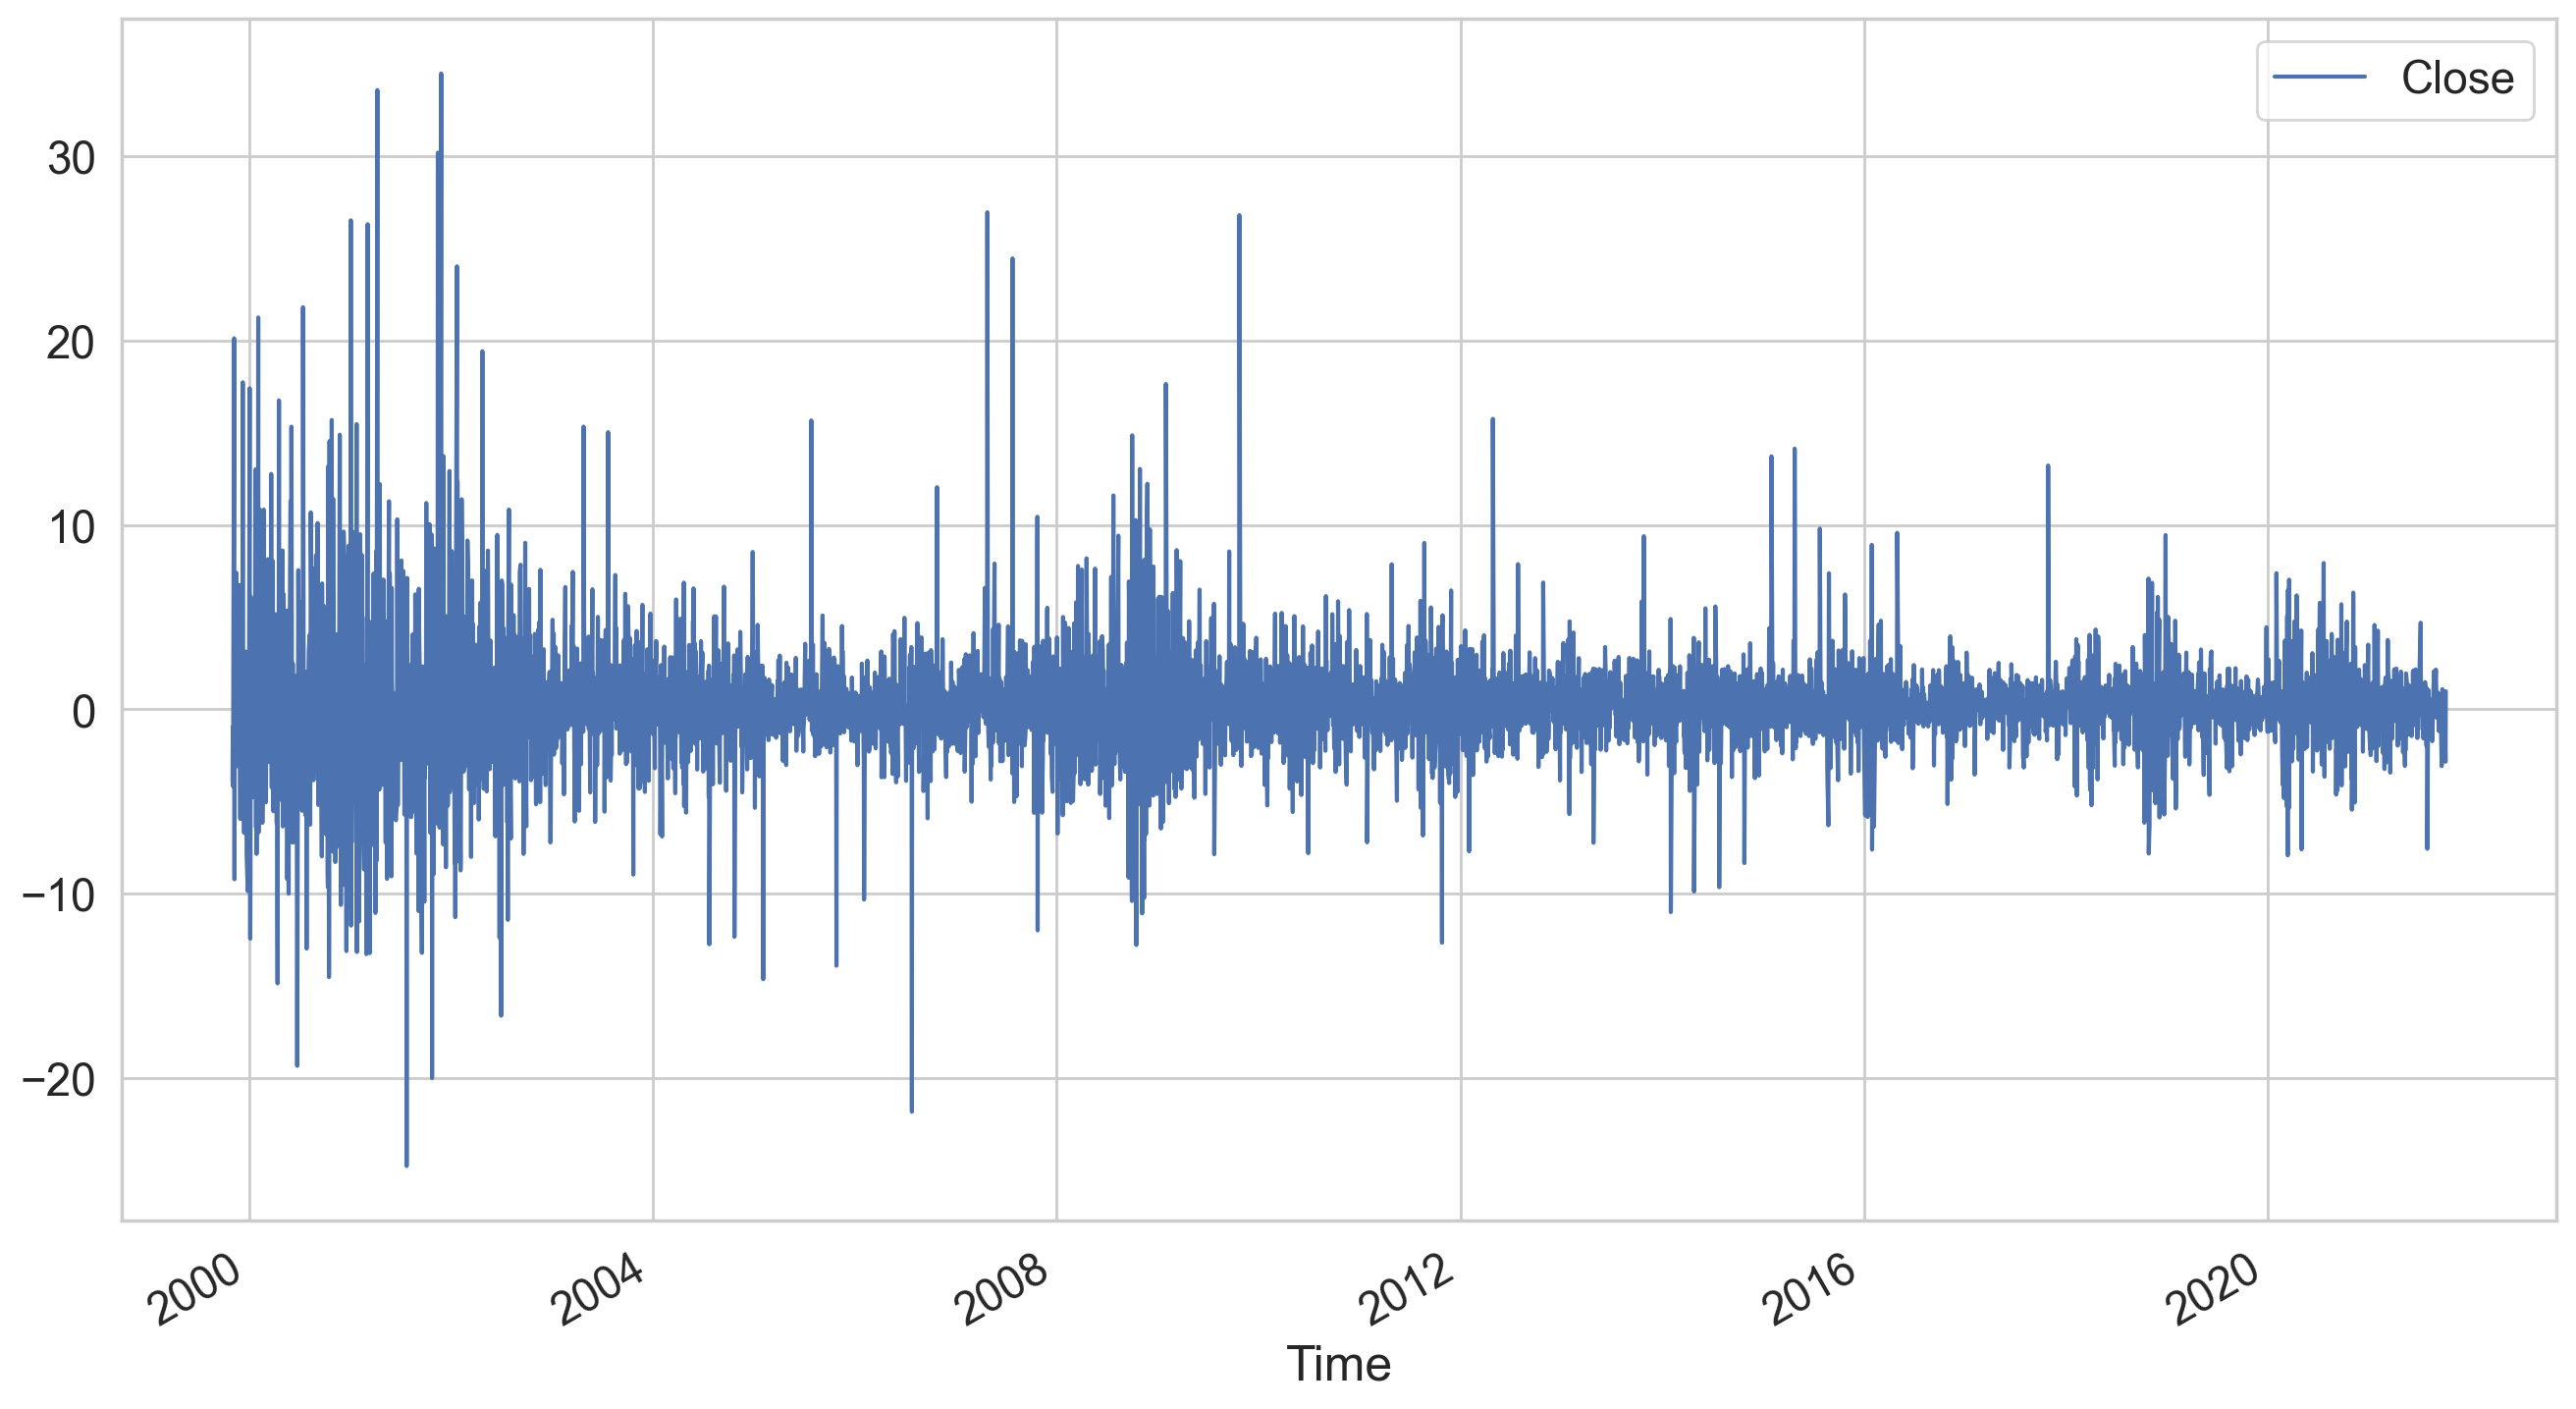

In [8]:
fig, ax = plt.subplots(figsize=(16,9))
data_ticker.plot(x="Time", y="Close", ax=ax)

## Create features

We will be working with classic machine learning methods in this assignment, so we must supply fixed sized input. In order to work with sequences of variable size within this setting, windowing is used. `tsfresh` provides windowing through `roll_time_series` function. Please familiarize yourself with its arguments and make sure to understand the operation it performs on the data.

In [9]:
from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import roll_time_series, make_forecasting_frame
from tsfresh.utilities.dataframe_functions import impute

In [10]:
data_rolled = roll_time_series(
    data_ticker,
    column_id="Ticker",
    column_sort="Time",
    max_timeshift=20,
    min_timeshift=5,
)

/Users/nstulov/miniconda3/envs/msai/lib/python3.12/site-packages/tsfresh/utilities/dataframe_functions.py:520: UserWarning: Your time stamps are not uniformly sampled, which makes rolling nonsensical in some domains.
  warnings.warn(
Rolling: 100%|██████████████████████████████████| 30/30 [00:02<00:00, 11.21it/s]


In [15]:
data_rolled.head(20)

,Time,Ticker,Close,id
3864,1999-11-01,AMZN,NaN,"(AMZN, 1999-11-08 00:00:00)"
3865,1999-11-02,AMZN,-3.891219,"(AMZN, 1999-11-08 00:00:00)"
3866,1999-11-03,AMZN,-0.948224,"(AMZN, 1999-11-08 00:00:00)"
3867,1999-11-04,AMZN,-4.178696,"(AMZN, 1999-11-08 00:00:00)"
3868,1999-11-05,AMZN,2.981288,"(AMZN, 1999-11-08 00:00:00)"
3869,1999-11-08,AMZN,20.110872,"(AMZN, 1999-11-08 00:00:00)"
3870,1999-11-01,AMZN,NaN,"(AMZN, 1999-11-09 00:00:00)"
3871,1999-11-02,AMZN,-3.891219,"(AMZN, 1999-11-09 00:00:00)"
3872,1999-11-03,AMZN,-0.948224,"(AMZN, 1999-11-09 00:00:00)"
3873,1999-11-04,AMZN,-4.178696,"(AMZN, 1999-11-09 00:00:00)"


In [13]:
import datetime

In [14]:
data_rolled[data_rolled["id"] == ('AMZN', datetime.datetime(1999, 11, 8))]

,Time,Ticker,Close,id
3864,1999-11-01,AMZN,NaN,"(AMZN, 1999-11-08 00:00:00)"
3865,1999-11-02,AMZN,-3.891219,"(AMZN, 1999-11-08 00:00:00)"
3866,1999-11-03,AMZN,-0.948224,"(AMZN, 1999-11-08 00:00:00)"
3867,1999-11-04,AMZN,-4.178696,"(AMZN, 1999-11-08 00:00:00)"
3868,1999-11-05,AMZN,2.981288,"(AMZN, 1999-11-08 00:00:00)"
3869,1999-11-08,AMZN,20.110872,"(AMZN, 1999-11-08 00:00:00)"


In [16]:
data_rolled[data_rolled["id"] == ('AMZN', datetime.datetime(1999, 11, 9))]

,Time,Ticker,Close,id
3870,1999-11-01,AMZN,NaN,"(AMZN, 1999-11-09 00:00:00)"
3871,1999-11-02,AMZN,-3.891219,"(AMZN, 1999-11-09 00:00:00)"
3872,1999-11-03,AMZN,-0.948224,"(AMZN, 1999-11-09 00:00:00)"
3873,1999-11-04,AMZN,-4.178696,"(AMZN, 1999-11-09 00:00:00)"
3874,1999-11-05,AMZN,2.981288,"(AMZN, 1999-11-09 00:00:00)"
3875,1999-11-08,AMZN,20.110872,"(AMZN, 1999-11-09 00:00:00)"
3876,1999-11-09,AMZN,-9.217949,"(AMZN, 1999-11-09 00:00:00)"


In [19]:
data_rolled[data_rolled["id"] == ('AMZN', datetime.datetime(2001, 11, 9))]

,Time,Ticker,Close,id
10443,2001-10-12,AMZN,2.802548,"(AMZN, 2001-11-09 00:00:00)"
10444,2001-10-15,AMZN,10.037175,"(AMZN, 2001-11-09 00:00:00)"
10445,2001-10-16,AMZN,7.657658,"(AMZN, 2001-11-09 00:00:00)"
10446,2001-10-17,AMZN,-6.694561,"(AMZN, 2001-11-09 00:00:00)"
10447,2001-10-18,AMZN,-5.044843,"(AMZN, 2001-11-09 00:00:00)"
10448,2001-10-19,AMZN,-5.430933,"(AMZN, 2001-11-09 00:00:00)"
10449,2001-10-22,AMZN,9.488140,"(AMZN, 2001-11-09 00:00:00)"
10450,2001-10-23,AMZN,8.893957,"(AMZN, 2001-11-09 00:00:00)"
10451,2001-10-24,AMZN,-20.000000,"(AMZN, 2001-11-09 00:00:00)"
10452,2001-10-25,AMZN,1.701571,"(AMZN, 2001-11-09 00:00:00)"


In [20]:
data_rolled["id"].nunique()

5513

Now that we have inputs of equal size (one `id` is one sample), we can create features for them using `tsfresh.extract_features`. Please familiarize yourself with its arguments.

In [79]:
X = extract_features(
    data_rolled.drop("Ticker", axis=1).fillna(0),
    column_id="id",
    column_sort="Time",
    column_value="Close",
    impute_function=impute,
    show_warnings=False
)

Feature Extraction: 100%|███████████████████████| 30/30 [00:17<00:00,  1.74it/s]


In [80]:
import holidays

In [81]:
us_holidays = holidays.country_holidays("US")

In [82]:
us_holidays

holidays.country_holidays('US')

In [83]:
def is_holiday_in_us(x):
    return x in us_holidays

In [85]:
X = X.set_index(X.index.map(lambda x: x[1]), drop=True)
X.index.name = "last_date"
X.shape

(5513, 783)

In [86]:
X["is_holiday_in_us"] = X.index.map(is_holiday_in_us)

In [87]:
X.columns

Index(['Close__variance_larger_than_standard_deviation',
       'Close__has_duplicate_max', 'Close__has_duplicate_min',
       'Close__has_duplicate', 'Close__sum_values', 'Close__abs_energy',
       'Close__mean_abs_change', 'Close__mean_change',
       'Close__mean_second_derivative_central', 'Close__median',
       ...
       'Close__fourier_entropy__bins_10', 'Close__fourier_entropy__bins_100',
       'Close__permutation_entropy__dimension_3__tau_1',
       'Close__permutation_entropy__dimension_4__tau_1',
       'Close__permutation_entropy__dimension_5__tau_1',
       'Close__permutation_entropy__dimension_6__tau_1',
       'Close__permutation_entropy__dimension_7__tau_1',
       'Close__query_similarity_count__query_None__threshold_0.0',
       'Close__mean_n_absolute_max__number_of_maxima_7', 'is_holiday_in_us'],
      dtype='object', length=784)

In [88]:
y = data_ticker.set_index("Time").sort_index()['Close'].shift(-1).dropna()

In [89]:
y_dummy = (
    data_ticker.set_index("Time").sort_index()['Close'].shift(-1) -
    data_ticker.set_index("Time").sort_index()['Close'] >= 0
)

In [90]:
y_dummy

Time
1999-11-01    False
1999-11-02     True
1999-11-03    False
1999-11-04     True
1999-11-05     True
              ...  
2021-09-29    False
2021-09-30     True
2021-10-01    False
2021-10-04     True
2021-10-05    False
Name: Close, Length: 5518, dtype: bool

In [91]:
data_ticker

,Time,Ticker,Close
0,1999-11-01,AMZN,NaN
1,1999-11-02,AMZN,-3.891219
2,1999-11-03,AMZN,-0.948224
3,1999-11-04,AMZN,-4.178696
4,1999-11-05,AMZN,2.981288
...,...,...,...
5513,2021-09-29,AMZN,-0.447533
5514,2021-09-30,AMZN,-0.487107
5515,2021-10-01,AMZN,-0.054185
5516,2021-10-04,AMZN,-2.847170


In [92]:
X.iloc[0].name

Timestamp('1999-11-08 00:00:00')

In [93]:
common_index = X.index.intersection(y.index)
X = X.loc[common_index]
y = y.loc[common_index]

In [94]:
y_dummy = y_dummy.loc[common_index]

In [95]:
X.iloc[0].name

Timestamp('1999-11-08 00:00:00')

In [96]:
y.index[0]

Timestamp('1999-11-08 00:00:00')

In [97]:
X_train = X[:"2018"]
X_test = X["2019":]

y_train = y[:"2018"]
y_test = y["2019":]

In [98]:
X_train.shape

(4817, 784)

In [99]:
y_dummy_train = y_dummy[:"2018"]

## Select features

`tsfresh` generates too many features for classic ML models that suffer from curse of dimensionality, so we need to choose the most representative features. `tsfresh` provides a function `select_features` for this purpose. You can use this function, or you can use PCA or any other feature selection / dimensionality reduction method that you know. If you choose to not use `tsfresh.select_features`, please still familiarize yourself with its arguments.

In [100]:
from tsfresh import select_features

In [101]:
X_train_selected = select_features(
    X_train, y_dummy_train
)

In [106]:
X_train_selected["is_holiday_in_us"] = X_train["is_holiday_in_us"]

In [107]:
X_train_selected.shape

(4817, 92)

In [108]:
"is_holiday_in_us" in X_train_selected.columns

True

In [109]:
X_test_selected = X_test[X_train_selected.columns]

In [110]:
X_train_selected.shape

(4817, 92)

In [111]:
from sklearn.decomposition import PCA

In [127]:
pca = PCA(n_components=10)
X_train_selected_pca = pca.fit_transform(X_train)
X_test_selected_pca = pca.transform(X_test)

## Preprocess features

You are welcome to perform some preprocessing steps that may improve the quality of your model. Please note that evaluation must be done on the original features.

In [114]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

In [128]:
scaler_pca = StandardScaler()
X_train_scaled_pca = scaler_pca.fit_transform(X_train_selected_pca)
X_test_scaled_pca = scaler_pca.transform(X_test_selected_pca)

## Baselines

I have created three baselines for you. Your task will be to beat at least the first one. If you beat the rolling mean baseline, you will get bonus points. You are also free to introduce our own baselines, e.g. linear regression.

In [116]:
from sklearn.metrics import mean_squared_error

In [117]:
mean_squared_error(y_test, y_test.shift(1).fillna(0))

7.498844073093679

In [118]:
mean_squared_error(y_test, np.ones_like(y_test) * y_test.mean())

3.5063685797153528

In [119]:
mean_squared_error(y_test, y_test.rolling(window=3, center=True).mean().bfill().ffill())

2.577951537001603

## Train a model

- Pick any ML model of your liking
- Fit it to the selected (and possibly preprocessed) features on the train set
- You can do cross-validation to pick hyperparameters, but be careful not to train on future!
- Make a prediction on the test set
- If necessay, make an inverse transform

In [120]:
from xgboost import XGBRegressor

In [138]:
xgb = XGBRegressor(n_estimators=100, max_depth=3, n_jobs=-1)

In [141]:
xgb.fit(X_train_selected, y_train)
y_pred = xgb.predict(X_test_selected)

In [142]:
xgb_pca = XGBRegressor(n_estimators=100, max_depth=3, n_jobs=-1)

In [143]:
xgb_pca.fit(X_train_selected_pca, y_train)
y_pred_pca = xgb_pca.predict(X_test_selected_pca)

## Compare quality

Please make a ualitative (plots) and quantitative (quality measures) comparison between your model and the baselines.

In [144]:
mean_squared_error(y_test, y_pred)

3.857667900653791

In [145]:
mean_squared_error(y_test, y_pred_pca)

3.9908063092578527

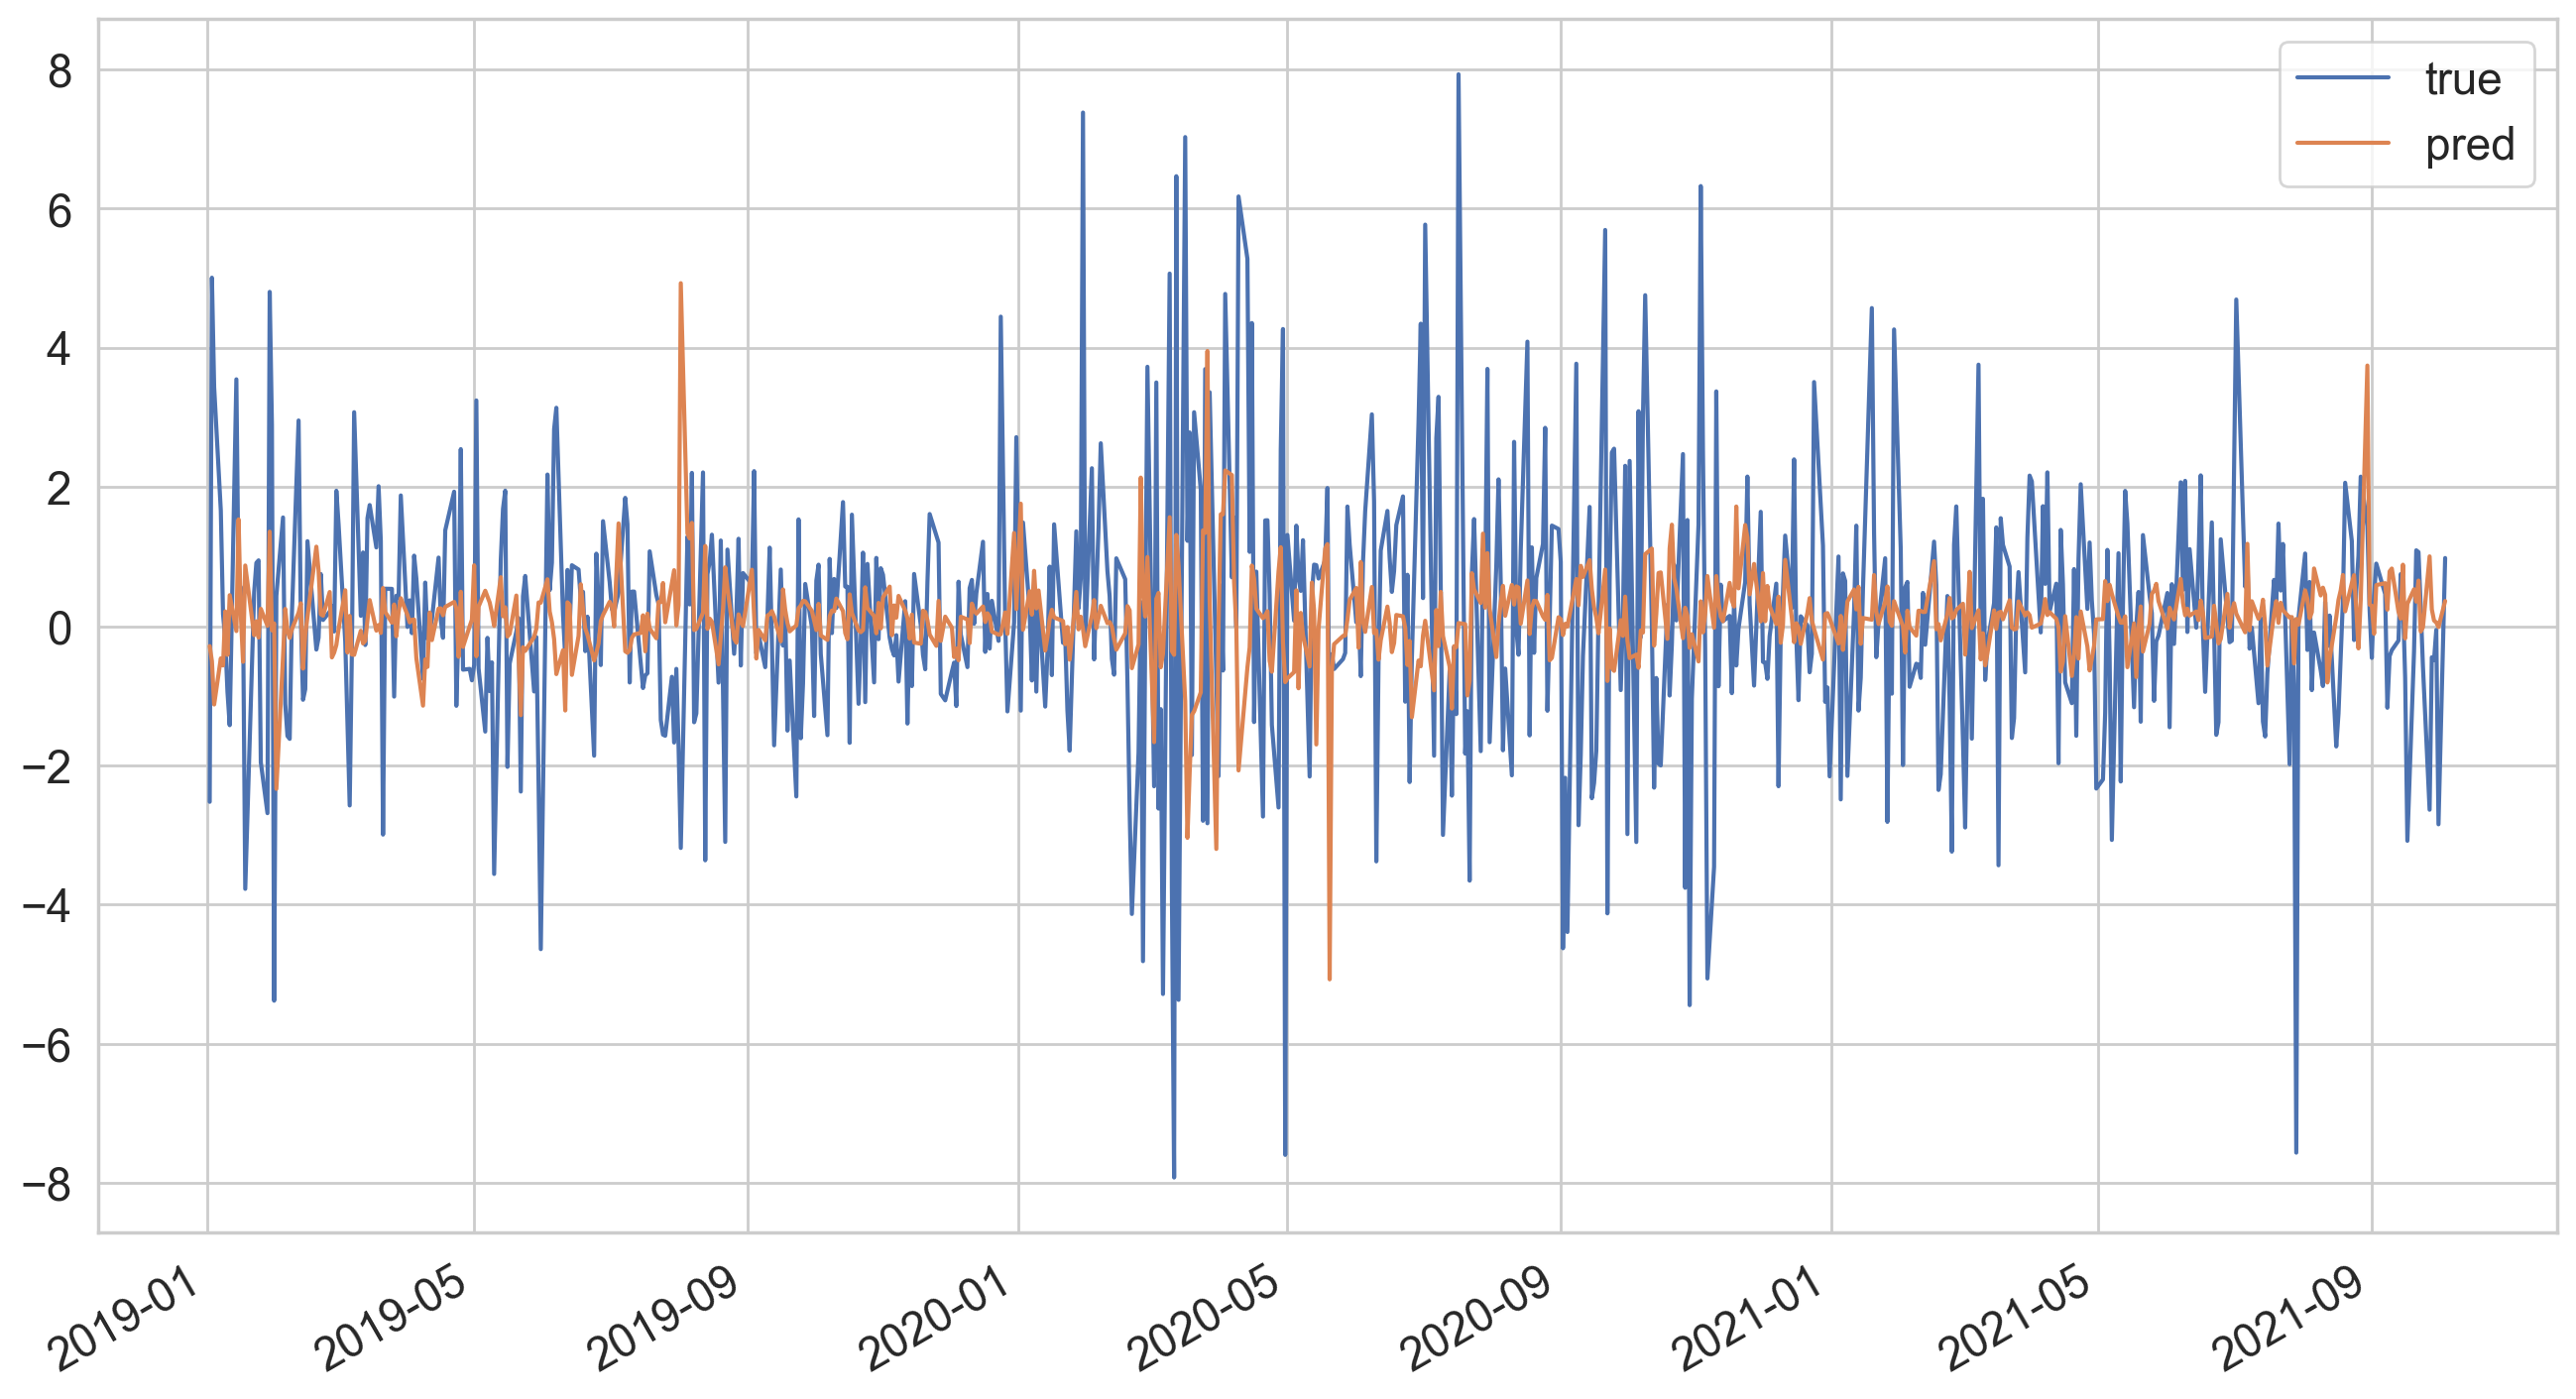

In [146]:
fig, ax = plt.subplots(figsize=(16,9))
y_test.plot(label="true", ax=ax)
pd.Series(y_pred, index=y_test.index).plot(label="pred", ax=ax)
ax.legend();